# 03 - Modeling, Model Selection & Production Pipeline
Goal: train multiple regression models to predict `Profit`, compare them with cross-validation, select the best one, and package it as a reusable production pipeline (saved with joblib).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42
df = pd.read_csv('../data/50_Startups_dataset.csv', index_col=0)
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.30,136897.90,471784.20,New York,192261.93
1,162597.80,151377.69,443898.63,California,191792.16
2,153441.61,101145.65,407934.64,Florida,191050.49
3,144372.51,118671.95,383199.72,New York,182902.09
4,142107.44,91391.87,366168.52,Florida,166188.04


## 1. Train / test split

In [ ]:
X = df.drop(columns=['Profit'])
y = df['Profit']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (40, 4) Test: (10, 4)


## 2. Preprocessing pipeline

Numeric columns are scaled; `State` is one-hot encoded. Wrapping preprocessing in a `ColumnTransformer` means the exact same transform is applied at train and inference time — no manual re-implementation risk.

In [ ]:
numeric_features = ['R&D Spend', 'Administration', 'Marketing Spend']
categorical_features = ['State']

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
])

## 3. Candidate models

In [ ]:
models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0, random_state=RANDOM_STATE),
    'Lasso': Lasso(alpha=1.0, random_state=RANDOM_STATE),
    'RandomForest': RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE),
    'GradientBoosting': GradientBoostingRegressor(random_state=RANDOM_STATE),
    'SVR': SVR(kernel='rbf', C=100, epsilon=1000),
}

pipelines = {
    name: Pipeline([('preprocess', preprocessor), ('model', model)])
    for name, model in models.items()
}
list(pipelines.keys())

['LinearRegression',
 'Ridge',
 'Lasso',
 'RandomForest',
 'GradientBoosting',
 'SVR']

## 4. Cross-validated comparison (5-fold, on training data)

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []

for name, pipe in pipelines.items():
    r2_scores = cross_val_score(pipe, X_train, y_train, cv=kf, scoring='r2')
    mae_scores = -cross_val_score(pipe, X_train, y_train, cv=kf, scoring='neg_mean_absolute_error')
    rmse_scores = -cross_val_score(pipe, X_train, y_train, cv=kf, scoring='neg_root_mean_squared_error')
    results.append({
        'Model': name,
        'CV_R2_mean': r2_scores.mean(), 'CV_R2_std': r2_scores.std(),
        'CV_MAE_mean': mae_scores.mean(),
        'CV_RMSE_mean': rmse_scores.mean(),
    })

results_df = pd.DataFrame(results).sort_values('CV_R2_mean', ascending=False).reset_index(drop=True)
results_df

,Model,CV_R2_mean,CV_R2_std,CV_MAE_mean,CV_RMSE_mean
0,RandomForest,0.945512,0.030975,7158.328240,9002.246990
1,Lasso,0.934049,0.032272,7423.838757,9548.009967
2,LinearRegression,0.934004,0.032301,7425.881525,9550.676106
3,Ridge,0.930445,0.037785,7715.994098,9725.867836
4,GradientBoosting,0.901301,0.032706,9186.346858,11717.838156
5,SVR,-0.274615,0.299216,35204.722344,42602.875527


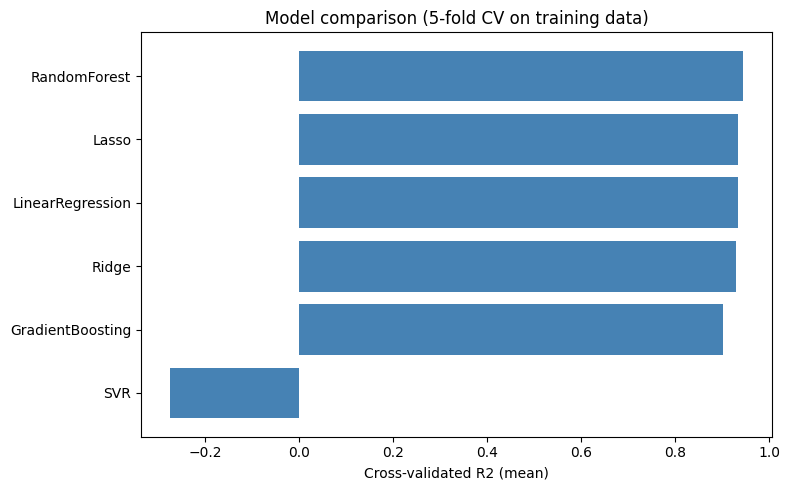

In [ ]:
plt.figure(figsize=(8,5))
plt.barh(results_df['Model'], results_df['CV_R2_mean'], color='steelblue')
plt.xlabel('Cross-validated R2 (mean)')
plt.title('Model comparison (5-fold CV on training data)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 5. Select best model, fit on full training set, evaluate on held-out test set

In [ ]:
best_model_name = results_df.iloc[0]['Model']
print("Best model by CV R2:", best_model_name)

best_pipeline = pipelines[best_model_name]
best_pipeline.fit(X_train, y_train)

y_pred = best_pipeline.predict(X_test)

test_metrics = {
    'R2': r2_score(y_test, y_pred),
    'MAE': mean_absolute_error(y_test, y_pred),
    'RMSE': mean_squared_error(y_test, y_pred) ** 0.5,
}
test_metrics

Best model by CV R2: RandomForest


{'R2': 0.8989355948596417, 'MAE': 6265.407030000014, 'RMSE': 9046.610095252501}

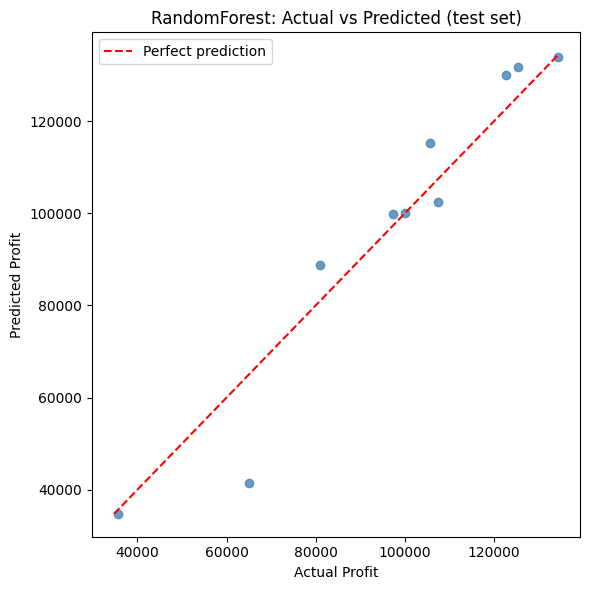

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, color='steelblue', alpha=0.8)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', label='Perfect prediction')
plt.xlabel('Actual Profit')
plt.ylabel('Predicted Profit')
plt.title(f'{best_model_name}: Actual vs Predicted (test set)')
plt.legend()
plt.tight_layout()
plt.show()

## 6. Refit best model on ALL data (final production model)

Once a model is selected via train/test + CV, refitting on the full dataset uses all available information for the deployed model.

In [ ]:
final_pipeline = pipelines[best_model_name]
final_pipeline.fit(X, y)

import os
os.makedirs('../model', exist_ok=True)
joblib.dump(final_pipeline, '../model/startup_profit_pipeline.joblib')

metadata = {
    'model_name': best_model_name,
    'features_numeric': numeric_features,
    'features_categorical': categorical_features,
    'target': 'Profit',
    'test_set_metrics': test_metrics,
    'cv_results': results_df.to_dict(orient='records'),
}
with open('../model/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Saved pipeline + metadata to ../model/")

Saved pipeline + metadata to ../model/


## 7. Production inference function

This is the function a production service would call — it loads the saved pipeline once and predicts on new raw records (same raw column format as the original CSV, minus `Profit`).

In [ ]:
def load_model(path='../model/startup_profit_pipeline.joblib'):
    return joblib.load(path)

def predict_profit(pipeline, records: list[dict]) -> np.ndarray:
    """records: list of dicts like
    {'R&D Spend': 100000, 'Administration': 120000, 'Marketing Spend': 300000, 'State': 'New York'}
    """
    new_df = pd.DataFrame(records)
    return pipeline.predict(new_df)

# Example usage
pipe = load_model()
sample = [{'R&D Spend': 120000, 'Administration': 110000, 'Marketing Spend': 250000, 'State': 'Florida'}]
predict_profit(pipe, sample)

array([144765.2596])

## Summary

- Compared 6 regression models (Linear, Ridge, Lasso, Random Forest, Gradient Boosting, SVR) using 5-fold cross-validation on R², MAE, and RMSE.
- Selected the best-performing model based on mean CV R², validated it on a held-out test set, then refit it on the full dataset for deployment.
- Packaged preprocessing + model together in a single `sklearn.Pipeline`, saved with `joblib` to `model/startup_profit_pipeline.joblib`, alongside `model/model_metadata.json` recording the chosen model, features, and metrics.
- Provided a minimal `load_model` / `predict_profit` interface that a production service (API, batch job, etc.) can call directly on new raw records — no manual preprocessing needed since it's baked into the pipeline.